In [5]:
import pandas as pd

In [4]:
pages = pd.read_csv('D:\Summer code\portfolio project\persian-cultural-rag-agent\Data\manifests/all_pages_report.csv')

In [5]:
pages.head()

,Id,url,title,relative_output_dir,status,attempt_count,started_at,finished_at,last_error,image_candidate_count,downloaded_image_count,accepted_count,review_count,rejected_count,selected_image_count,failed_selected_image_count,skipped_selected_image_count,selected_without_local_path_count,scraped_title,download_decisions
0,9316,https://fa.wikipedia.org/wiki/%D8%A2%D8%A8%E2%...,آب‌انبار حاج کاظم,data/pages/9316_آب_انبار_حاج_کاظم,done,1,2026-06-22T16:52:56+00:00,2026-06-22T16:53:02+00:00,NaN,5,2,1,1,3,2,0,0,0,آب‌انبار حاج کاظم,accept|review
1,9317,https://fa.wikipedia.org/wiki/%D8%A2%D8%A8%E2%...,آب‌انبار سردار کوچک,data/pages/9317_آب_انبار_سردار_کوچک,done,1,2026-06-22T16:52:56+00:00,2026-06-22T16:52:59+00:00,NaN,1,1,0,1,0,1,0,0,0,آب‌انبار سردار کوچک,accept|review
2,9318,https://fa.wikipedia.org/wiki/%D8%A2%D8%AA%D8%...,آتشکده آمل,data/pages/9318_آتشکده_آمل,done,1,2026-06-22T16:52:56+00:00,2026-06-22T16:53:20+00:00,NaN,15,8,8,0,7,8,0,0,0,آتشکده آمل,accept|review
3,9319,https://fa.wikipedia.org/wiki/%D8%A2%D8%AA%D8%...,آتشکده اسپاخو,data/pages/9319_آتشکده_اسپاخو,done,1,2026-06-22T16:53:00+00:00,2026-06-22T16:53:03+00:00,NaN,8,1,1,0,7,1,0,0,0,آتشکده اسپاخو,accept|review
4,9320,https://fa.wikipedia.org/wiki/%D8%A2%D8%AA%D8%...,آتشکده جره,data/pages/9320_آتشکده_جره,done,1,2026-06-22T16:53:02+00:00,2026-06-22T16:53:05+00:00,NaN,4,1,1,0,3,1,0,0,0,آتشکده جره,accept|review


# Schema 

pageid 
url 
title 
node type 
chunkid
    


In [2]:
import json
from pathlib import Path

# مسیر پوشه اصلی صفحات
base_dir = Path(r"D:\Summer code\portfolio project\persian-cultural-rag-agent\Data\pages_no_photos")
output_file = Path(r"D:\Summer code\portfolio project\persian-cultural-rag-agent\Data\final_pages_data.json")

combined_data = []

# پیمایش تمام پوشه‌های موجود در pages_no_photos
for folder in base_dir.iterdir():
    if folder.is_dir():
        metadata_path = folder / "page_metadata.json"
        content_path = folder / "page_content.json"
        text_path = folder / "page_text.txt"

        # بررسی وجود فایل‌های اصلی
        if metadata_path.exists() and content_path.exists():
            # ۱. خواندن metadata
            with open(metadata_path, "r", encoding="utf-8") as f:
                metadata = json.load(f)

            # ۲. خواندن page_content
            with open(content_path, "r", encoding="utf-8") as f:
                page_content = json.load(f)

            # ۳. خواندن text (در صورت وجود)
            page_text = ""
            if text_path.exists():
                with open(text_path, "r", encoding="utf-8") as f:
                    page_text = f.read()

            # استخراج فیلدهای مورد نظر
            page_id = metadata.get("Id")
            node_type = metadata.get("source_row", {}).get("node_type")
            unique_id = f"page_{page_id}"

            # ساخت دیکشنری نهایی برای این صفحه
            record = {
                "unique_id": unique_id,
                "id": page_id,
                "node_type": node_type,
                "text": page_text,
                "page_content": page_content
            }

            combined_data.append(record)

# ذخیره خروجی نهایی به صورت یک فایل JSON جامع
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(combined_data, f, ensure_ascii=False, indent=2)

print(f"تعداد {len(combined_data)} صفحه با موفقیت پردازش و ذخیره شد.")

تعداد 4271 صفحه با موفقیت پردازش و ذخیره شد.


combnsion اولیه

یکسری ادیت ها از جمله مرتب کردن اسکیما

In [3]:
from pathlib import Path
import json

# ۱. تعریف مسیرها
base_dir = Path(r"D:\Summer code\portfolio project\persian-cultural-rag-agent\Data\pages_no_photos")
output_dir = Path(r"D:\Summer code\portfolio project\persian-cultural-rag-agent\Data\processed")
output_file = output_dir / "final_pages_data.json"

# ساخت پوشه خروجی در صورت عدم وجود
output_dir.mkdir(parents=True, exist_ok=True)

if not base_dir.exists():
    raise FileNotFoundError(f"پوشه ورودی یافت نشد:\n{base_dir}")

combined_data = []

# ۲. پیمایش و ویرایش ساختار داده
for folder in base_dir.iterdir():
    if folder.is_dir():
        metadata_path = folder / "page_metadata.json"
        content_path = folder / "page_content.json"
        text_path = folder / "page_text.txt"

        if metadata_path.exists() and content_path.exists():
            with open(metadata_path, "r", encoding="utf-8") as f:
                metadata = json.load(f)

            with open(content_path, "r", encoding="utf-8") as f:
                page_content = json.load(f)

            page_text = ""
            if text_path.exists():
                with open(text_path, "r", encoding="utf-8") as f:
                    page_text = f.read()

            # استخراج داده‌های متا
            page_id = metadata.get("Id")
            node_type = metadata.get("source_row", {}).get("node_type")

            # جدا کردن page_url و title از page_content و حذف full_text
            page_url = page_content.pop("page_url", None)
            title = page_content.pop("title", None)
            page_content.pop("full_text", None)  # حذف full_text از داخل page_content

            # ساخت رکورد جدید با ساختار مورد نظر شما
            record = {
                "unique_id": f"page_{page_id}",
                "id": page_id,
                "node_type": node_type,
                "page_url": page_url,
                "title": title,
                "text": page_text,
                "page_content": page_content  # شامل lead و sections
            }
            combined_data.append(record)

# ۳. ذخیره خروجی
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(combined_data, f, ensure_ascii=False, indent=2)

print(f"پردازش انجام شد. خروجی در مسیر زیر ذخیره گردید:\n{output_file.resolve()}")

پردازش انجام شد. خروجی در مسیر زیر ذخیره گردید:
D:\Summer code\portfolio project\persian-cultural-rag-agent\Data\processed\final_pages_data.json


In [6]:
combined_df = pd.read_json(output_file)

In [ ]:
combined_df

,unique_id,id,node_type,page_url,title,text,page_content
0,page_10001,10001,page,https://fa.wikipedia.org/wiki/%D9%82%D9%84%D8%...,قلعه بردستان,قلعه بردستان\n\nقلعه بردستان مربوط به دوران‌ها...,{'lead': 'قلعه بردستان مربوط به دوران‌های تاری...
1,page_10004,10004,page,https://fa.wikipedia.org/wiki/%D9%82%D9%84%D8%...,قلعه بزم,قلعه بزم\n\nقلعه بزم مربوط به سده‌ها متاخر دور...,{'lead': 'قلعه بزم مربوط به سده‌ها متاخر دوران...
2,page_10005,10005,page,https://fa.wikipedia.org/wiki/%D9%82%D9%84%D8%...,قلعه بزنجرد,قلعه بزنجرد\n\nقلعهٔ بزنجرد یا دژ بیژن‌گرد نام...,{'lead': 'قلعهٔ بزنجرد یا دژ بیژن‌گرد نام دژی ...
3,page_10007,10007,page,https://fa.wikipedia.org/wiki/%D9%82%D9%84%D8%...,قلعه بندبن,قلعه بندبن\n\nقلعه بندبن از مهم‌ترین و زیبا‌تر...,{'lead': 'قلعه بندبن از مهم‌ترین و زیبا‌ترین آ...
4,page_10008,10008,page,https://fa.wikipedia.org/wiki/%D9%82%D9%84%D8%...,قلعه بوینی یوغون,قلعه بوینی یوغون\n\nقلعه بوینی یوغون (قلعه آدم...,{'lead': 'قلعه بوینی یوغون (قلعه آدم خوار) این...


In [11]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (919 > 512). Running this sequence through the model will result in indexing errors


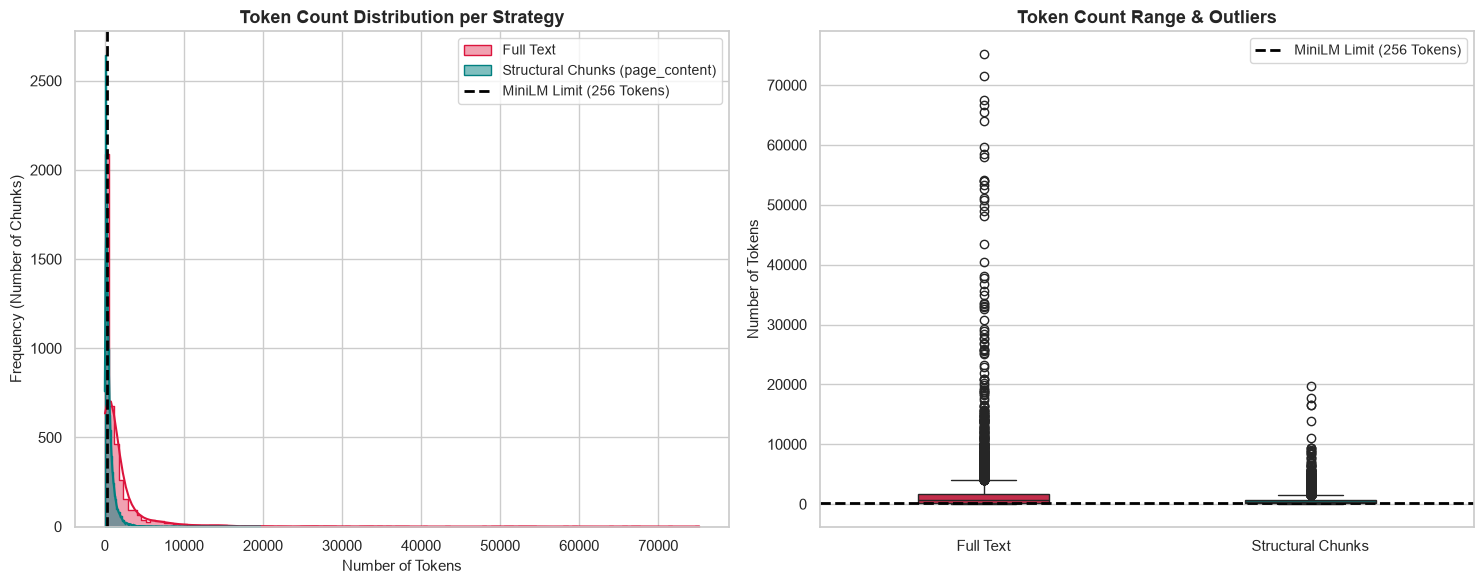

In [12]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from transformers import AutoTokenizer

# ۱. بارگذاری توکنایزر مدل all-MiniLM-L6-v2
tokenizer_name = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

# ۲. بارگذاری فایل JSON
json_path = Path(r"D:\Summer code\portfolio project\persian-cultural-rag-agent\Data\processed\final_pages_data.json")

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

full_text_tokens = []
structural_chunk_tokens = []

# ۳. محاسبه تعداد توکن‌ها در هر دو استراتژی
for item in data:
    # روش اول: توکن‌های کل متن (Full Text)
    text = item.get("text", "")
    if text:
        tokens_count = len(tokenizer.encode(text, truncation=False))
        full_text_tokens.append(tokens_count)

    # روش دوم: توکن‌های چانک‌های ساختاری (page_content)
    page_content = item.get("page_content", {})
    
    # بخش Lead
    lead_text = page_content.get("lead", "")
    if lead_text:
        structural_chunk_tokens.append(len(tokenizer.encode(lead_text, truncation=False)))
    
    # بخش‌های Sections
    sections = page_content.get("sections", [])
    for sec in sections:
        sec_text = sec.get("text", "")
        if sec_text:
            structural_chunk_tokens.append(len(tokenizer.encode(sec_text, truncation=False)))

# ۴. رسم نمودارها
plt.figure(figsize=(15, 6))
sns.set_theme(style="whitegrid")

# نمودار اول: توزیع فراوانی تعداد توکن‌ها (Histogram + KDE)
plt.subplot(1, 2, 1)
sns.histplot(full_text_tokens, color="crimson", label="Full Text", kde=True, element="step", alpha=0.4)
sns.histplot(structural_chunk_tokens, color="teal", label="Structural Chunks (page_content)", kde=True, element="step", alpha=0.5)

# خط آستانه ۲۵۶ توکن (سقف مدل MiniLM)
plt.axvline(x=256, color="black", linestyle="--", linewidth=2, label="MiniLM Limit (256 Tokens)")

plt.title("Token Count Distribution per Strategy", fontsize=13, fontweight="bold")
plt.xlabel("Number of Tokens", fontsize=11)
plt.ylabel("Frequency (Number of Chunks)", fontsize=11)
plt.legend(fontsize=10)

# نمودار دوم: باکس‌پلات برای بررسی چگالی و مقادیر پرت (Boxplot)
plt.subplot(1, 2, 2)
sns.boxplot(
    data=[full_text_tokens, structural_chunk_tokens],
    palette=["crimson", "teal"],
    width=0.4
)
plt.axhline(y=256, color="black", linestyle="--", linewidth=2, label="MiniLM Limit (256 Tokens)")

plt.xticks([0, 1], ["Full Text", "Structural Chunks"], fontsize=11)
plt.title("Token Count Range & Outliers", fontsize=13, fontweight="bold")
plt.ylabel("Number of Tokens", fontsize=11)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [13]:
import json
from pathlib import Path
import pandas as pd

# ۱. بارگذاری فایل داده‌ها
json_path = Path(r"D:\Summer code\portfolio project\persian-cultural-rag-agent\Data\processed\final_pages_data.json")

with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"=== گزارش تحلیل اولیه داده‌ها (تعداد کل رکوردها: {len(data)}) ===\n")

# ---------------------------------------------------------
# ۱. تحلیل متون خالی (Empty Text Check)
# ---------------------------------------------------------
empty_text_count = 0
empty_lead_count = 0
empty_sections_count = 0

for item in data:
    # بررسی متن اصلی
    if not item.get("text") or not item.get("text").strip():
        empty_text_count += 1
    
    # بررسی page_content
    pc = item.get("page_content", {})
    if not pc.get("lead") or not pc.get("lead").strip():
        empty_lead_count += 1
    
    # بررسی بخش‌ها
    sections = pc.get("sections", [])
    if not sections:
        empty_sections_count += 1
    else:
        for sec in sections:
            if not sec.get("text") or not sec.get("text").strip():
                empty_sections_count += 1
                break

print("[1] Empty Text Analysis:")
print(f"  - رکوردهای با متن اصلی خالی (empty text): {empty_text_count}")
print(f"  - رکوردهای با lead خالی: {empty_lead_count}")
print(f"  - رکوردهای بدون section یا دارای section خالی: {empty_sections_count}\n")

# ---------------------------------------------------------
# ۲. تحلیل تکراری‌ها (Duplicate Handling Analysis)
# ---------------------------------------------------------
df = pd.DataFrame(data)

duplicate_ids = df[df.duplicated(subset=["id"], keep=False)]
duplicate_urls = df[df.duplicated(subset=["page_url"], keep=False)]
duplicate_texts = df[df.duplicated(subset=["text"], keep=False)]

print("[2] Duplicate Handling Analysis:")
print(f"  - تعداد IDهای تکراری: {len(duplicate_ids)}")
print(f"  - تعداد URLهای تکراری: {len(duplicate_urls)}")
print(f"  - تعداد متون کاملاً تکراری: {len(duplicate_texts)}\n")

# ---------------------------------------------------------
# ۳. تحلیل شناسه‌های پایدار (Stable IDs Analysis)
# ---------------------------------------------------------
missing_unique_ids = df["unique_id"].isnull().sum()
invalid_id_format = df[~df["unique_id"].astype(str).str.startswith("page_")]

print("[3] Stable IDs Analysis:")
print(f"  - رکوردهای فاقد unique_id: {missing_unique_ids}")
print(f"  - رکوردهایی با فرمت غیر استاندارد ID: {len(invalid_id_format)}")
print("  - پیشنهاد Stable ID برای چانک‌ها: [page_id]#lead و [page_id]#sec_[index]\n")

# ---------------------------------------------------------
# ۴. اعتبارسنجی متاداده‌ها (Metadata Validation Analysis)
# ---------------------------------------------------------
missing_urls = df["page_url"].isnull().sum()
missing_titles = df["title"].isnull().sum()
missing_node_types = df["node_type"].isnull().sum()

print("[4] Metadata Validation Analysis:")
print(f"  - عنوان (title) مفقود: {missing_titles}")
print(f"  - آدرس (page_url) مفقود: {missing_urls}")
print(f"  - نوع گره (node_type) مفقود: {missing_node_types}\n")

# ---------------------------------------------------------
# ۵. تست اعتبارسنجی اسکیما (Schema Validation Tests)
# ---------------------------------------------------------
schema_errors = []

for idx, item in enumerate(data):
    if not isinstance(item.get("id"), str):
        schema_errors.append(f"Index {idx}: 'id' must be a string")
    if not isinstance(item.get("page_content"), dict):
        schema_errors.append(f"Index {idx}: 'page_content' must be a dict")
    elif "sections" in item["page_content"] and not isinstance(item["page_content"]["sections"], list):
        schema_errors.append(f"Index {idx}: 'sections' must be a list")

print("[5] Schema Validation Tests:")
print(f"  - تعداد خطاهای اسکیما/تایپ داده: {len(schema_errors)}")
if schema_errors:
    print(f"  - نمونه خطاها: {schema_errors[:3]}")

=== گزارش تحلیل اولیه داده‌ها (تعداد کل رکوردها: 4271) ===

[1] Empty Text Analysis:
  - رکوردهای با متن اصلی خالی (empty text): 0
  - رکوردهای با lead خالی: 15
  - رکوردهای بدون section یا دارای section خالی: 2257

[2] Duplicate Handling Analysis:
  - تعداد IDهای تکراری: 58
  - تعداد URLهای تکراری: 58
  - تعداد متون کاملاً تکراری: 72

[3] Stable IDs Analysis:
  - رکوردهای فاقد unique_id: 0
  - رکوردهایی با فرمت غیر استاندارد ID: 0
  - پیشنهاد Stable ID برای چانک‌ها: [page_id]#lead و [page_id]#sec_[index]

[4] Metadata Validation Analysis:
  - عنوان (title) مفقود: 0
  - آدرس (page_url) مفقود: 0
  - نوع گره (node_type) مفقود: 0

[5] Schema Validation Tests:
  - تعداد خطاهای اسکیما/تایپ داده: 0
